# Regresión Logística para predecir la supervivencia de pasajeros del Titanic

**Estudiante:** María Isabel Hernández Bello  
**Universidad:** Universidad de Cundinamarca  
**Materia:** Introducción a Machine Learning  

## Objetivo

Construir un modelo de Regresión Logística para predecir si un pasajero del Titanic sobrevivió o no, utilizando características como la clase del pasajero, edad, número de familiares a bordo y tarifa pagada.

## Importación de librerías

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

## Carga del dataset

In [2]:
import seaborn as sns

datos = sns.load_dataset("titanic")

datos.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


## Exploración de los datos

In [3]:
print("Filas y columnas:", datos.shape)

print("\nInformación del dataset:")
datos.info()

Filas y columnas: (891, 15)

Información del dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


In [4]:
datos.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [5]:
datos["survived"].value_counts()

,count
survived,
0,549
1,342


## Preparación de los datos

In [6]:
datos_modelo = datos[[
    "survived",
    "pclass",
    "age",
    "sibsp",
    "parch",
    "fare"
]].copy()

datos_modelo = datos_modelo.dropna()

print("Datos después de eliminar valores nulos:", datos_modelo.shape)

datos_modelo.head()

Datos después de eliminar valores nulos: (714, 6)


,survived,pclass,age,sibsp,parch,fare
0,0,3,22.0,1,0,7.2500
1,1,1,38.0,1,0,71.2833
2,1,3,26.0,0,0,7.9250
3,1,1,35.0,1,0,53.1000
4,0,3,35.0,0,0,8.0500


## Visualización

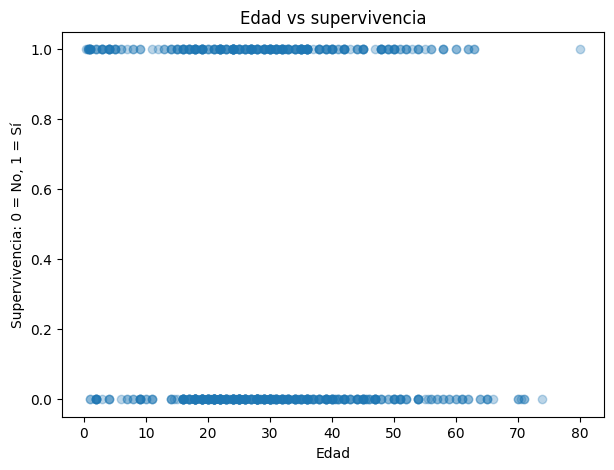

In [7]:
plt.figure(figsize=(7,5))

plt.scatter(datos_modelo["age"], datos_modelo["survived"], alpha=0.3)

plt.xlabel("Edad")
plt.ylabel("Supervivencia: 0 = No, 1 = Sí")
plt.title("Edad vs supervivencia")

plt.show()

### Interpretación

La gráfica permite observar la distribución de los pasajeros según su edad y condición de supervivencia. Debido a que la variable objetivo es binaria, los valores se concentran en 0 y 1. La visualización permite identificar que la supervivencia no depende únicamente de la edad, por lo que se utilizarán varias variables para construir el modelo.

## Definición de X e y

In [8]:
X = datos_modelo[[
    "pclass",
    "age",
    "sibsp",
    "parch",
    "fare"
]]

y = datos_modelo["survived"]

print("Variables de entrada:")
print(X.head())

print("\nVariable objetivo:")
print(y.head())

Variables de entrada:
   pclass   age  sibsp  parch     fare
0       3  22.0      1      0   7.2500
1       1  38.0      1      0  71.2833
2       3  26.0      0      0   7.9250
3       1  35.0      1      0  53.1000
4       3  35.0      0      0   8.0500

Variable objetivo:
0    0
1    1
2    1
3    1
4    0
Name: survived, dtype: int64


## División de entrenamiento y prueba

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

print("Tamaño X_train:", X_train.shape)
print("Tamaño X_test:", X_test.shape)

print("\nDistribución entrenamiento:")
print(y_train.value_counts())

print("\nDistribución prueba:")
print(y_test.value_counts())

Tamaño X_train: (535, 5)
Tamaño X_test: (179, 5)

Distribución entrenamiento:
survived
0    318
1    217
Name: count, dtype: int64

Distribución prueba:
survived
0    106
1     73
Name: count, dtype: int64


In [10]:
modelo = LogisticRegression(max_iter=1000)

modelo.fit(X_train, y_train)

print("Modelo entrenado correctamente.")

Modelo entrenado correctamente.


## Predicciones y probabilidades

In [11]:
y_pred = modelo.predict(X_test)

probabilidades = modelo.predict_proba(X_test)

print("Clases predichas:")
print(y_pred[:10])

print("\nProbabilidades:")
print(probabilidades[:10])

Clases predichas:
[0 0 0 0 0 1 0 1 1 0]

Probabilidades:
[[0.65311043 0.34688957]
 [0.55817643 0.44182357]
 [0.79876428 0.20123572]
 [0.79552057 0.20447943]
 [0.79545077 0.20454923]
 [0.2611156  0.7388844 ]
 [0.76726062 0.23273938]
 [0.30422248 0.69577752]
 [0.40244148 0.59755852]
 [0.82009083 0.17990917]]


## Comparación de valores reales y predichos

In [12]:
comparacion = pd.DataFrame({
    "Real": y_test.values,
    "Predicho": y_pred,
    "Probabilidad_No": probabilidades[:, 0],
    "Probabilidad_Si": probabilidades[:, 1]
})

comparacion.head(10)

,Real,Predicho,Probabilidad_No,Probabilidad_Si
0,0,0,0.653110,0.346890
1,0,0,0.558176,0.441824
2,1,0,0.798764,0.201236
3,0,0,0.795521,0.204479
4,0,0,0.795451,0.204549
5,0,1,0.261116,0.738884
6,0,0,0.767261,0.232739
7,1,1,0.304222,0.695778
8,0,1,0.402441,0.597559
9,0,0,0.820091,0.179909


## Evaluación del modelo

In [13]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

matriz = confusion_matrix(y_test, y_pred)

print("\nMatriz de confusión:")
print(matriz)

print("\nReporte de clasificación:")
print(classification_report(y_test, y_pred))

Accuracy: 0.7039106145251397

Matriz de confusión:
[[89 17]
 [36 37]]

Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.71      0.84      0.77       106
           1       0.69      0.51      0.58        73

    accuracy                           0.70       179
   macro avg       0.70      0.67      0.68       179
weighted avg       0.70      0.70      0.69       179



In [14]:
prob_supervivencia = probabilidades[:, 1]

umbral = 0.60

y_pred_umbral = (prob_supervivencia >= umbral).astype(int)

comparacion_umbral = pd.DataFrame({
    "Real": y_test.values,
    "Probabilidad_Supervivencia": prob_supervivencia,
    "Predicho_umbral_0.60": y_pred_umbral
})

comparacion_umbral.head(10)

,Real,Probabilidad_Supervivencia,Predicho_umbral_0.60
0,0,0.346890,0
1,0,0.441824,0
2,1,0.201236,0
3,0,0.204479,0
4,0,0.204549,0
5,0,0.738884,1
6,0,0.232739,0
7,1,0.695778,1
8,0,0.597559,0
9,0,0.179909,0


## Cambio del umbral de decisión

In [15]:
print("Predicciones con umbral 0.50:", (prob_supervivencia >= 0.50).sum())
print("Predicciones con umbral 0.60:", (prob_supervivencia >= 0.60).sum())

print("\nAccuracy con umbral 0.50:",
      accuracy_score(y_test, y_pred))

print("Accuracy con umbral 0.60:",
      accuracy_score(y_test, y_pred_umbral))

Predicciones con umbral 0.50: 54
Predicciones con umbral 0.60: 34

Accuracy con umbral 0.50: 0.7039106145251397
Accuracy con umbral 0.60: 0.7039106145251397


In [16]:
print("Matriz de confusión con umbral 0.60:")
print(confusion_matrix(y_test, y_pred_umbral))

print("\nReporte de clasificación con umbral 0.60:")
print(classification_report(y_test, y_pred_umbral))

Matriz de confusión con umbral 0.60:
[[99  7]
 [46 27]]

Reporte de clasificación con umbral 0.60:
              precision    recall  f1-score   support

           0       0.68      0.93      0.79       106
           1       0.79      0.37      0.50        73

    accuracy                           0.70       179
   macro avg       0.74      0.65      0.65       179
weighted avg       0.73      0.70      0.67       179



## Preguntas de análisis

### 1. ¿Por qué este ejercicio es de clasificación y no de regresión?

Este ejercicio corresponde a un problema de clasificación porque la variable objetivo `survived` tiene dos categorías: 0, que representa que el pasajero no sobrevivió, y 1, que representa que sí sobrevivió. El modelo busca asignar cada pasajero a una de estas dos clases.

### 2. ¿Qué significa que la variable `survived` tenga valores 0 y 1?

El valor 0 representa que el pasajero no sobrevivió, mientras que el valor 1 representa que el pasajero sobrevivió. Estos valores permiten utilizar la Regresión Logística para realizar una clasificación binaria.

### 3. ¿Qué hace `fit()` en el modelo?

El método `fit()` permite entrenar el modelo utilizando los datos de entrenamiento. Durante este proceso, la Regresión Logística aprende la relación entre las variables de entrada y la variable objetivo.

### 4. ¿Qué diferencia hay entre `predict()` y `predict_proba()`?

`predict()` entrega directamente la clase predicha por el modelo, mientras que `predict_proba()` entrega las probabilidades estimadas de pertenecer a cada clase. En este ejercicio, `predict_proba()` permite conocer la probabilidad estimada de supervivencia.

### 5. ¿Qué indica la matriz de confusión en este ejercicio?

La matriz de confusión permite identificar los aciertos y errores del modelo. Con el umbral de 0,50 se obtuvieron 89 verdaderos negativos, 17 falsos positivos, 36 falsos negativos y 37 verdaderos positivos. Al utilizar un umbral de 0,60, se obtuvieron 99 verdaderos negativos, 7 falsos positivos, 46 falsos negativos y 27 verdaderos positivos.

### 6. ¿Qué métrica considera más útil para interpretar el resultado y por qué?

En este ejercicio es importante analizar varias métricas conjuntamente y no solamente el Accuracy. El Recall de la clase 1 permite observar qué proporción de los pasajeros que realmente sobrevivieron fue identificada correctamente por el modelo. También es útil revisar Precision y F1-score para obtener una visión más completa del desempeño.

### 7. ¿Qué podría pasar si el conjunto de datos fuera mucho más grande y estuviera desbalanceado?

Si una clase tuviera muchos más registros que la otra, el Accuracy podría dar una impresión poco representativa del desempeño del modelo. Por esta razón sería importante revisar la matriz de confusión, Precision, Recall y F1-score para conocer cómo se comporta el modelo en cada clase.

## Resultados

El modelo de Regresión Logística obtuvo un Accuracy de 0,7039, equivalente a 70,39 % en el conjunto de prueba.

Con el umbral de decisión de 0,50, la matriz de confusión fue:

- Verdaderos negativos: 89
- Falsos positivos: 17
- Falsos negativos: 36
- Verdaderos positivos: 37

Para la clase 0, el modelo obtuvo Precision = 0,71, Recall = 0,84 y F1-score = 0,77. Para la clase 1, obtuvo Precision = 0,69, Recall = 0,51 y F1-score = 0,58.

Al modificar el umbral a 0,60, la cantidad de predicciones de la clase 1 disminuyó de 54 a 34. La matriz de confusión cambió a:

- Verdaderos negativos: 99
- Falsos positivos: 7
- Falsos negativos: 46
- Verdaderos positivos: 27.

El Accuracy se mantuvo en 70,39 %, aunque cambiaron los tipos de errores cometidos por el modelo.

## Conclusiones

El ejercicio permitió implementar un modelo de Regresión Logística para predecir la supervivencia de pasajeros del Titanic a partir de variables como la clase del pasajero, edad, número de familiares a bordo y tarifa pagada.

El modelo obtuvo un Accuracy de 70,39 %, lo que indica que aproximadamente 7 de cada 10 predicciones realizadas sobre el conjunto de prueba fueron correctas. La matriz de confusión y las métricas de Precision, Recall y F1-score permitieron analizar con mayor detalle los aciertos y errores del modelo.

Para la clase de pasajeros que sobrevivieron, el modelo obtuvo un Recall de 0,51 con el umbral de 0,50, lo que indica que identificó aproximadamente la mitad de los casos que realmente pertenecían a esta clase.

Al cambiar el umbral de decisión de 0,50 a 0,60, disminuyeron las predicciones de supervivencia de 54 a 34. También disminuyeron los falsos positivos de 17 a 7, mientras que los falsos negativos aumentaron de 36 a 46. El Accuracy permaneció en 70,39 %, mostrando que una misma exactitud puede acompañarse de diferentes tipos de errores.

En conclusión, el ejercicio permitió comprender el proceso básico de clasificación mediante Regresión Logística, incluyendo la preparación de los datos, entrenamiento del modelo, generación de predicciones, estimación de probabilidades y evaluación mediante diferentes métricas.

## Metodología

Para desarrollar el ejercicio se utilizó el conjunto de datos Titanic y se seleccionaron como variables predictoras la clase del pasajero (`pclass`), edad (`age`), número de hermanos o cónyuges a bordo (`sibsp`), número de padres o hijos a bordo (`parch`) y tarifa pagada (`fare`).

La variable objetivo fue `survived`, donde 0 representa que el pasajero no sobrevivió y 1 que sobrevivió. Los registros con valores faltantes en las variables seleccionadas fueron eliminados antes de construir el modelo.

Los datos se dividieron en un 75 % para entrenamiento y un 25 % para prueba, utilizando `random_state=42` y `stratify=y`. Posteriormente se entrenó un modelo de Regresión Logística mediante Scikit-learn.

El modelo fue evaluado utilizando Accuracy, matriz de confusión, Precision, Recall y F1-score. También se analizaron las probabilidades generadas mediante `predict_proba()` y se modificó el umbral de decisión de 0,50 a 0,60 para observar los cambios en las predicciones.